# 03-02 - Red Is Not Red, Bands and an Index

The lecture ended its second week on a picture of Princeton in which the golf course was red, and asked why. This notebook answers in code. A sensor does not record colours. It records brightness in a few chosen slices of the spectrum, called bands, and a colour picture is a decision about which band to show through which of the three channels of a screen. Make the ordinary decision and grass is green. Make a different one and everything that reflects near infrared light, which is to say every leaf, turns red.

We take the bands apart on the State's 2020 orthophoto of the field, compose the ordinary picture and the infrared one, and read why the trees are grey in one and the turf red in the other. Then we move to the satellite, whose numbers are reflectance rather than brightness, and compute the vegetation index that the lecture read at five places in town, on a cloudless August pass and on a bare March one. We follow three pixels through every pass of a year, which shows the season in a line, and we end in the feature space of red against near infrared, where the index turns out to be an angle.

The ground truth file carries the numbers the lecture quoted, and every value we compute is printed beside its reference. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

## Four bands, one photograph

The State's file holds four bands, and 03-01 read their order off the descriptions: near infrared first, then red, green and blue. Each band is a grey picture on its own, a map of how much light in one part of the spectrum reached the camera from each square foot of ground:

bands             ('near infrared', 'red', 'green', 'blue')
coordinate system EPSG:3424
cell              1.0 US survey foot


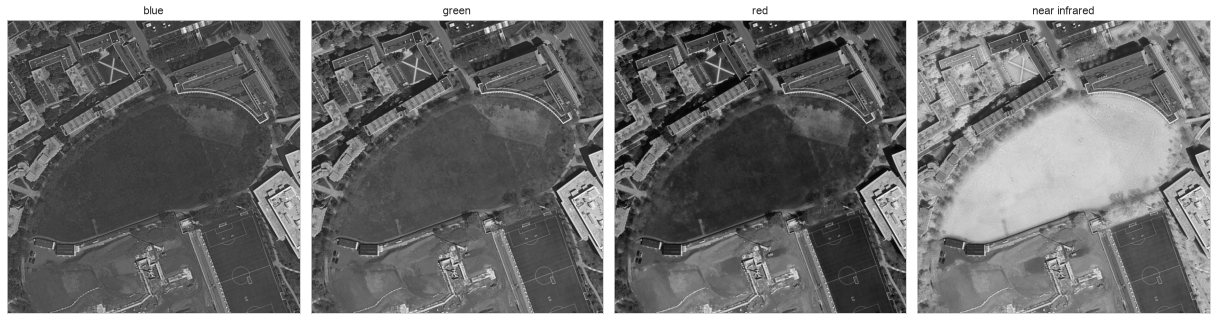

In [2]:
with rasterio.open("data/nj2020_site_1ft.tif") as f:
    print("bands            ", f.descriptions)
    print("coordinate system", f.crs)
    print("cell             ", f.res[0], f.crs.linear_units)
    nir, red, green, blue = f.read()                     # in the order the descriptions gave, near infrared first
    extent = (f.bounds.left, f.bounds.right, f.bounds.bottom, f.bounds.top)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
for ax, (name, band) in zip(axes, (("blue", blue), ("green", green), ("red", red), ("near infrared", nir))):
    ax.imshow(band, cmap="gray", extent=extent, vmin=0, vmax=255)
    ax.set_title(name, fontsize=11); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

Look at the field across the four panels. In blue and in red it is dark, because a leaf absorbs those colours to drive photosynthesis. In green it is a little brighter, which is the little the leaf gives back and the reason we call it green. In near infrared it is the brightest thing in the picture, because the inside of a leaf scatters that light almost completely. The roofs and the paths are bright in every band, having no reason to prefer one, and the bare trees, in this leaf-off season, are dark grey everywhere, because there is no leaf to scatter anything.

A screen can show three of these at once, one through each of its red, green and blue channels. Send the red band to the red channel, green to green and blue to blue, and you have a photograph as an eye would have seen it. Shift everything down one channel, near infrared into red, red into green and green into blue, and you have the colour infrared picture of the lecture:

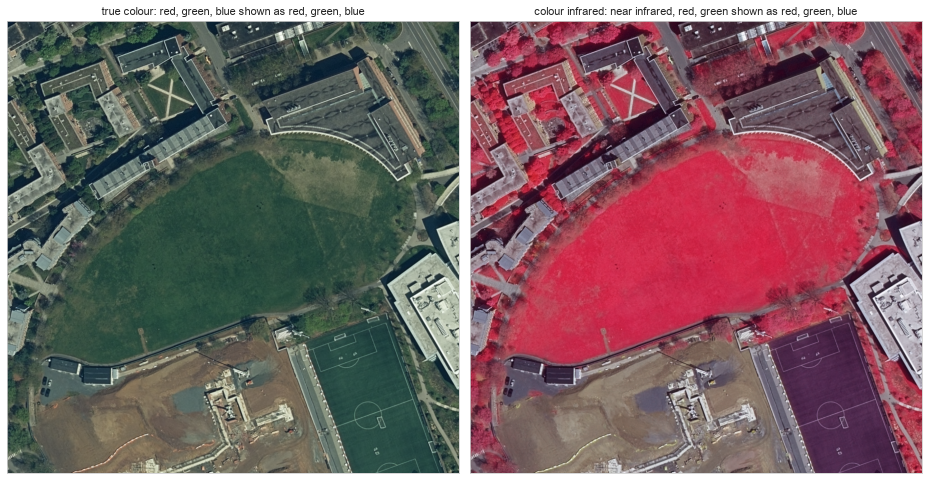

In [3]:
def compose(r, g, b):
    return np.moveaxis(np.stack([r, g, b]), 0, -1)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.6))
axes[0].imshow(compose(red, green, blue), extent=extent)
axes[0].set_title("true colour: red, green, blue shown as red, green, blue", fontsize=11)
axes[1].imshow(compose(nir, red, green), extent=extent)
axes[1].set_title("colour infrared: near infrared, red, green shown as red, green, blue", fontsize=11)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

Same four numbers per pixel, two pictures. On the right everything that was bright in near infrared is now red, which is the turf, the evergreen hedges and nothing else, because this is a leaf-off flight and the deciduous trees have no leaves to scatter with. Look at the bottom right of the two pictures. The athletics pitch is as green as the field in true colour and dark in the infrared, because artificial turf is a plastic that reflects green for the eye and nothing for the leaf's reason; the infrared picture tells you what is alive. That is the whole answer to the lecture's question. The golf course was red because a fairway is a sheet of leaves, and it was red in a colour infrared picture because someone chose to show the near infrared band through the red channel. Red is not red. It is a band, shown as a colour, by a choice.

The choice is not arbitrary. The eye is excellent at telling reds apart, and the near infrared band is where healthy vegetation separates most sharply from everything else, so the infrared composite has been the photo interpreter's favourite for eighty years. But it means that a colour in a remote sensing picture is a statement about the display, and you should always ask which band it is before you believe it.

## Reflectance, and the two numbers on the item

The State's bands are eight bit brightness, rendered for the eye, and 03-01 showed why that limits what you can compute from them. The satellite's bands are different in kind. Sentinel-2's Level 2A product gives reflectance, the fraction of the sun's light in each band that the ground sent back, corrected for the atmosphere, so a value means the same thing on every day and every tile. The file we ship is the 4 km campus window of the pass of 22 August 2025, and its tags say what was done to it:

In [4]:
with rasterio.open("data/s2_20250822_campus_10m.tif") as f:
    band_names = [d.split()[0] for d in f.descriptions]      # "red reflectance" is band number 3 and we call it "red"
    s2 = {name: f.read(i + 1) for i, name in enumerate(band_names)}
    s2_extent = (f.bounds.left, f.bounds.right, f.bounds.bottom, f.bounds.top)
    s2_crs = f.crs
    for key in ("item", "datetime", "platform", "note", "scale_offset_note"):
        print(f"{key:18} {f.tags()[key]}")
    print(f"{'cloud cover':18} {float(f.tags()['cloud_cover']):.2f} percent of the tile")
for name, band in s2.items():
    print(f"{name:6} reflectance from {band.min():.4f} to {band.max():.4f}, median {np.median(band):.3f}")

item               S2C_18TWK_20250822_0_L2A
datetime           2025-08-22T16:02:21.073000+00:00
platform           sentinel-2c
note               reflectance after the item's raster:bands scale, and its offset unless earthsearch:boa_offset_applied
scale_offset_note  reflectance, the item's scale and offset already applied; do not apply them again
cloud cover        0.03 percent of the tile
blue   reflectance from 0.0001 to 1.7688, median 0.031
green  reflectance from 0.0001 to 1.6680, median 0.054
red    reflectance from 0.0001 to 1.6104, median 0.038
nir    reflectance from 0.0054 to 1.5496, median 0.265


The stored numbers on the satellite are counts, and the catalogue attaches two numbers to every item, a scale and an offset, that turn a count into a reflectance. Since the processing baseline of early 2022 the offset is a thousand counts, added so that a dark pixel never goes negative, and it must be subtracted before the scale is applied. The pipeline that pinned this file did both, and the tag says so. Read the four lines it printed. The three visible bands sit at a few percent, near infrared at about a quarter, which is the leaf's signature of 03-01 in numbers, and each band's maximum climbs past one, which a reflectance should not do; those are the handful of roofs and cars that reflect the sun straight into the sensor, and they are why a picture is stretched to its percentiles rather than to its extremes. Do it twice, as many first attempts on live catalogue data do, and every reflectance drops by 0.1 in absolute terms, water goes negative and the index you are about to compute is quietly wrong. Do it not at all and your index is compressed toward zero, because the thousand counts sit in both the numerator and the denominator. P04 pulls these files live and will meet both numbers on the item itself.

## The vegetation index at five places

The normalised difference vegetation index is one line of arithmetic: near infrared minus red, over near infrared plus red. A leaf reflects a great deal of near infrared and very little red, so its index approaches one; soil and concrete reflect the two about equally, so their index sits near zero; water reflects red faintly and near infrared almost not at all, so its index is negative. The normalisation by the sum makes the index independent of how bright the day was, which is why it can be compared across dates.

The lecture read it at five places, and those places travel in `site.gpkg` as a layer of points, each with a sentence on how it was placed:

In [5]:
def ndvi(nir, red):
    '''The normalised difference vegetation index of two reflectances, whole arrays or single numbers alike.'''
    nir, red = np.asarray(nir, dtype="float32"), np.asarray(red, dtype="float32")
    return (nir - red) / (nir + red)

index_aug = ndvi(s2["nir"], s2["red"])
places = gpd.read_file("data/site.gpkg", layer="places").to_crs(s2_crs)
reference = json.load(open("data/ground_truth.json"))["p03"]
with rasterio.open("data/s2_20250822_campus_10m.tif") as f:
    readings = list(f.sample([(p.x, p.y) for p in places.geometry]))
for (name, how), reading in zip(places[["name", "how"]].values, readings):
    blue, green, red_here, nir_here = reading              # the file's four bands, in the order the descriptions gave
    print(f"{name:16} red {red_here:.3f}  nir {nir_here:.3f}  NDVI {ndvi(nir_here, red_here):+.2f}"
          f"   reference {reference['ndvi']['places_20250822'][name]:+.3f}   ({how})")

golf fairway     red 0.009  nir 0.246  NDVI +0.93   reference +0.931   (the greenest 10 m Sentinel-2 pixel of the Springdale golf course on 2025-08-22)
campus lawn      red 0.046  nir 0.333  NDVI +0.76   reference +0.759   (the centroid of Poe Field, the site)
Institute Woods  red 0.018  nir 0.312  NDVI +0.89   reference +0.888   (the centroid of the Institute Woods)
Nassau Street    red 0.119  nir 0.151  NDVI +0.12   reference +0.120   (the point of Nassau Street nearest Nassau Hall)
Lake Carnegie    red 0.019  nir 0.010  NDVI -0.31   reference -0.312   (the darkest near infrared 10 m pixel of Lake Carnegie on 2025-08-22)


Nine tenths on the golf fairway and in the Institute Woods, three quarters on the campus lawn, which is Poe Field itself, a tenth on Nassau Street and a negative third on Lake Carnegie. Those are the lecture's numbers, and they are the shape of the index: dense green leaves near the top, a lawn that has been walked on a little lower, built ground near zero, water below it.

Here is the index for the whole window, with the five places on it:

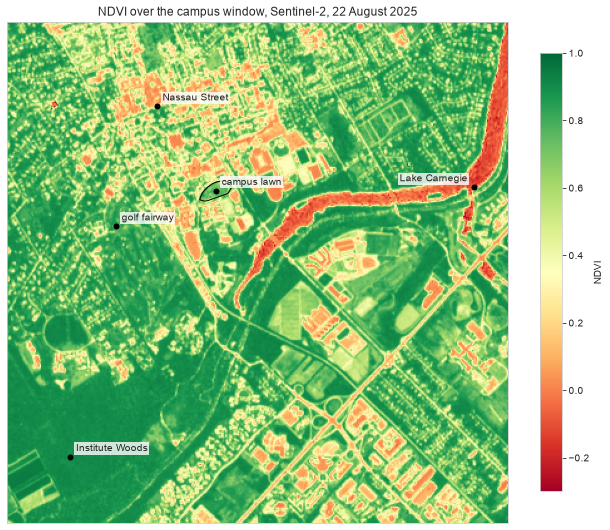

In [6]:
site = gpd.read_file("data/site.gpkg", layer="site").to_crs(s2_crs)
fig, ax = plt.subplots(figsize=(9, 9))
im = ax.imshow(index_aug, extent=s2_extent, cmap="RdYlGn", vmin=-0.3, vmax=1.0)
site.boundary.plot(ax=ax, color="black", linewidth=1)
places.plot(ax=ax, color="black", markersize=25)
for name, geom in zip(places["name"], places.geometry):
    near_right_edge = geom.x > s2_extent[0] + 0.8 * (s2_extent[1] - s2_extent[0])
    ax.annotate(name, (geom.x, geom.y), xytext=(-6 if near_right_edge else 6, 6), textcoords="offset points", fontsize=10,
                ha="right" if near_right_edge else "left", bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))
ax.set_title("NDVI over the campus window, Sentinel-2, 22 August 2025", fontsize=12)
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, shrink=0.7, label="NDVI")
fig.tight_layout()

The map is what the town looks like to a plant. The woods and the golf course are deep green, the campus a mosaic of lawn and roof, the town centre yellow, and the lake red. Note what the index does not say. It cannot tell a maple from an oak, a lawn from a soy field, or a healthy tree from a stressed one that still has its leaves, and above about 0.8 it saturates, so the densest canopy and a denser one read the same. It is one number, and a good one, but it is a measure of how much green leaf is in a pixel, not of what the pixel is.

## Leaf-off, leaf-on

Now the same five places on the clearest pass of the following March, when the deciduous trees were bare:

S2B_18TWK_20250310_0_L2A, 2025-03-10, sentinel-2b, cloud cover 0.01 percent of the tile
                 August  March  reference August  reference March
name                                                             
golf fairway       0.93   0.50             0.931            0.500
campus lawn        0.76   0.63             0.759            0.632
Institute Woods    0.89   0.35             0.888            0.349
Nassau Street      0.12   0.05             0.120            0.051
Lake Carnegie     -0.31  -0.58            -0.312           -0.580


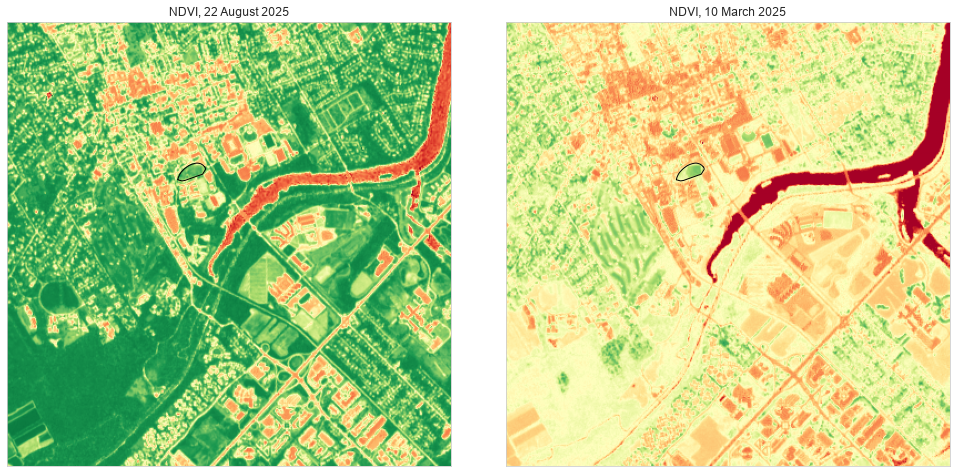

In [7]:
with rasterio.open("data/s2_20250310_campus_10m.tif") as f:
    march = {d.split()[0]: f.read(i + 1) for i, d in enumerate(f.descriptions)}     # the same four bands, the same names
    print(f"{f.tags()['item']}, {f.tags()['datetime'][:10]}, {f.tags()['platform']}, cloud cover {float(f.tags()['cloud_cover']):.2f} percent of the tile")
    readings_march = list(f.sample([(p.x, p.y) for p in places.geometry]))
index_march = ndvi(march["nir"], march["red"])

table = pd.DataFrame({
    "August": [ndvi(nir_here, red_here) for blue, green, red_here, nir_here in readings],
    "March": [ndvi(nir_here, red_here) for blue, green, red_here, nir_here in readings_march],
}, index=places["name"]).round(2)
table["reference August"] = [reference["ndvi"]["places_20250822"][name] for name in places["name"]]
table["reference March"] = [reference["ndvi"]["places_20250310"][name] for name in places["name"]]
print(table.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6.6))
for ax, (title, index) in zip(axes, (("22 August 2025", index_aug), ("10 March 2025", index_march))):
    ax.imshow(index, extent=s2_extent, cmap="RdYlGn", vmin=-0.3, vmax=1.0)
    site.boundary.plot(ax=ax, color="black", linewidth=1)
    ax.set_title(f"NDVI, {title}", fontsize=12); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

The Institute Woods fall from nine tenths to a third, because a deciduous forest without leaves is, to the index, mostly branches and ground. The fairway halves, because cool season turf goes dormant and brown, and the campus lawn drops least of the three green places. Nassau Street barely moves, since concrete has no season. The lake moves most of all and downward, which is not a statement about vegetation at all; a water surface reflects almost no near infrared in either month, so its index is a small difference between two small numbers and it swings with the wind, the sediment and the angle of the sun. The woods are not less forest in March. The index measured leaves, and there were none. Every comparison of two dates in this course, and the satellite land cover classifier of P04 in particular, has to reckon with the season before it reckons with change.

## A year at three pixels

Sentinel-2 passed over this tile 168 times in 2025, on 154 different days. The kit carries the index of three of the five pixels for every one of those passes, together with the scene classification the product attaches to each pixel, a code that says whether the satellite believed it saw vegetation, bare ground, water, cloud or shadow. The passes the classification calls clear are the ones worth reading:

168 passes on 154 dates; 184 clear readings of 504
scl_name
cloud high probability      162
vegetation                  159
cloud medium probability     97
thin cirrus                  43
not vegetated                25
cloud shadow                 11
snow or ice                   4
unclassified                  3
Institute Woods  65 clear readings, NDVI 0.15 to 0.91, above 0.5 from 2025-04-23 to 2025-10-26   reference 2025-04-23 to 2025-10-26
campus lawn      58 clear readings, NDVI 0.39 to 0.87, above 0.5 from 2025-01-04 to 2025-12-22   reference 2025-01-04 to 2025-12-22
golf fairway     61 clear readings, NDVI 0.26 to 0.97, above 0.5 from 2025-01-14 to 2025-12-22   reference 2025-01-14 to 2025-12-22


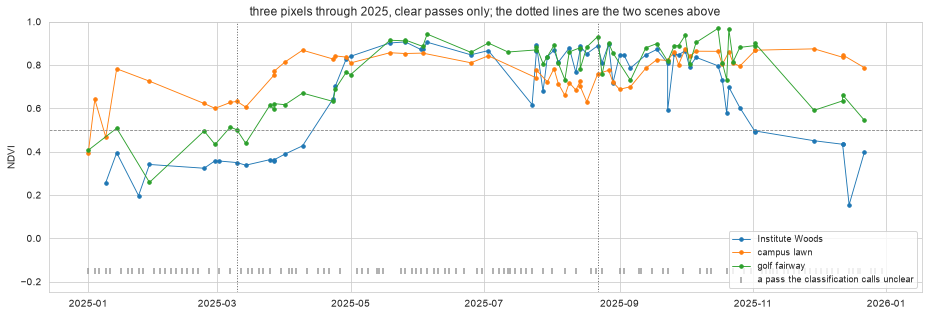

In [8]:
year = pd.read_csv("data/ndvi_year.csv", parse_dates=["date"])
clear = year[year["clear"]]
print(f"{year['item'].nunique()} passes on {year['date'].nunique()} dates; {int(year['clear'].sum())} clear readings of {len(year)}")
print(year["scl_name"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(13, 4.5))
for name, g in clear.groupby("place"):
    ax.plot(g["date"], g["ndvi"], marker="o", markersize=3.5, linewidth=0.9, label=name)
unclear = year[~year["clear"]].drop_duplicates("date")
ax.scatter(unclear["date"], np.full(len(unclear), -0.15), marker="|", color="0.6", label="a pass the classification calls unclear")
for day in ("2025-03-10", "2025-08-22"):
    ax.axvline(pd.Timestamp(day), color="0.4", linestyle=":", linewidth=1)
ax.axhline(0.5, color="0.5", linestyle="--", linewidth=0.8)
ax.set_ylim(-0.25, 1.0); ax.set_ylabel("NDVI"); ax.legend(loc="lower right", fontsize=9)
ax.set_title("three pixels through 2025, clear passes only; the dotted lines are the two scenes above", fontsize=12)
fig.tight_layout()

for name, g in clear.groupby("place"):
    above = g[g["ndvi"] >= 0.5]
    ref = reference["ndvi"]["year"]["places"][name]
    print(f"{name:16} {len(g):2d} clear readings, NDVI {g['ndvi'].min():.2f} to {g['ndvi'].max():.2f}, above 0.5 from {above['date'].min():%Y-%m-%d} to {above['date'].max():%Y-%m-%d}"
          f"   reference {ref['first_above_0_5']} to {ref['last_above_0_5']}")

The woods are a curve. They stay low until late April, climb steeply as the leaves come out, hold a plateau near nine tenths all summer, and fall through October into a bare winter. The two turf places never fall that far, because turf keeps some leaf all winter, and the printed lines say how far that goes: both of them are above the half line in the first half of January, so neither has a spring in the sense the woods have one. This is phenology, the calendar of plants, read from orbit, and the two dotted lines show where the March and the August scenes sit in it.

Note two things about the grey ticks along the bottom. There are a great many of them, since fewer than two passes in five were clear at these pixels, and a year of satellite data is mostly cloud. And the classification that sorted them is itself a product with errors. It is made by an algorithm from the same pixels, it calls shadow cloud and bright roofs snow now and then, and a careful analyst reads it as advice rather than truth. The first table above counts how often each label occurred.

## The feature space

One last way to see the index. Plot thirty thousand cells of the August window, drawn at random from the hundred and sixty thousand so that the picture is a cloud rather than a solid block, red reflectance across and near infrared up. Vegetation climbs the left side, where red is low and near infrared high; bare ground and roofs lie along a diagonal where the two are alike; water huddles near the origin. Lines from the origin are lines of constant NDVI, because the index depends only on the ratio of the two, and the five places fall where their numbers said:

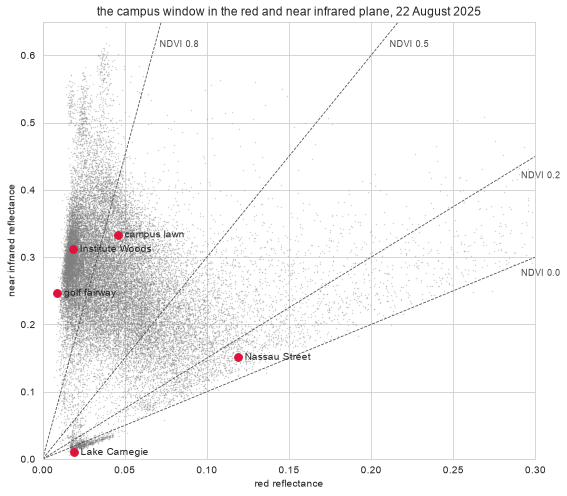

In [9]:
valid = (s2["red"] > 0) & (s2["nir"] > 0)     # true everywhere in this file, since it has no nodata cells; the habit matters in 03-06
rng = np.random.default_rng(3)
pick = rng.choice(np.flatnonzero(valid), 30000, replace=False)
r_all, n_all = s2["red"].ravel()[pick], s2["nir"].ravel()[pick]

red_max, nir_max = 0.3, 0.65                           # the frame of the plot, used by the labels below as well
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(r_all, n_all, s=2, color="0.5", alpha=0.35, linewidths=0)
for value in (0.0, 0.2, 0.5, 0.8):
    slope = (1 + value) / (1 - value)                      # nir / red on a line of constant NDVI
    x = np.array([0, red_max])
    ax.plot(x, slope * x, color="0.3", linewidth=0.8, linestyle="--")
    x_label = min(red_max - 0.01, (nir_max - 0.02) / slope)   # where the line leaves the frame, at the right or at the top
    ax.annotate(f"NDVI {value}", (x_label, slope * x_label), xytext=(2, -12), textcoords="offset points", fontsize=9, color="0.3")
for name, (b, g, r, n) in zip(places["name"], readings):
    ax.scatter(r, n, s=60, color="crimson", zorder=3)
    ax.annotate(name, (r, n), xytext=(7, 0), textcoords="offset points", fontsize=10, va="center")
ax.set_xlim(0, red_max); ax.set_ylim(0, nir_max)
ax.set_xlabel("red reflectance"); ax.set_ylabel("near infrared reflectance")
ax.set_title("the campus window in the red and near infrared plane, 22 August 2025", fontsize=12)
fig.tight_layout()

The cloud of points is the town. Its lower edge, running diagonally from the origin, is the soil line, where bare surfaces of every brightness lie; its tall left shoulder is the vegetation, and the higher a point sits above the soil line the more leaf is in its pixel. Every point lies on a ray from the origin, and NDVI is a measure of that ray's slope, folded into a number between minus one and one; the soil line is simply the ray where it is near zero. The dashed lines show what that buys: one value of the index is a whole ray of very different brightnesses. That is what "normalised" buys: the fairway in full sun and the fairway under a thin haze fall on the same ray.

## Your turn

Turn the index into a map of "green" and count it. Take the August index, call every cell at or above 0.5 green, and compute the share of the window that is green. Then do it again at 0.3. The two shares will differ by a good margin, and the sentence to write is why a threshold is a decision rather than a measurement, and which of the two you would defend for a map of the town's tree canopy.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [10]:
# Your attempt. index_aug is the August NDVI array and valid marks the cells with data, which here is all of them.
#
# for threshold in (___, ___):
#     green = index_aug[valid] >= threshold
#     print(f"at {threshold}: {green.mean():.1%} of the window is green")
#
# fig, ax = plt.subplots(figsize=(7, 7))
# ax.imshow(index_aug >= ___, extent=s2_extent, cmap="Greens")
# site.boundary.plot(ax=ax, color="black", linewidth=1)

## Check your understanding

1. In the colour infrared picture the turf is red and the trees are grey. Which band makes the difference, why do the trees not share it in this picture, and what would change in August?
2. A colleague computes NDVI on Sentinel-2 counts without the offset and gets 0.6 for the woods where you get 0.9. Explain the direction of the error in one sentence.
3. The Institute Woods read 0.89 in August and 0.35 in March. Name two changes on the ground that would produce the same pair of numbers, and one measurement that would tell them apart.
4. Two pixels have red and near infrared of (0.04, 0.36) and (0.08, 0.72). What are their indices, and what does the answer tell you about what the index cannot see?

## Where we are

You can take a multiband image apart into its bands, compose a true colour and a colour infrared picture from them, and explain why a leaf is red in one and green in the other. You know the difference between a rendered brightness and a reflectance, and what the two numbers on a catalogue item are for. You can compute NDVI, read it at a point and over a window, and you have seen it change with the season at five places and through a whole year at three. And you know the index as an angle in the feature space, which is where P04's classifier will draw its first line.

The habit worth keeping: before comparing two images, ask what their numbers mean, and before comparing two dates, ask what season each one is.

In 03-03 we plan the flight of 23 September, from the camera's pixel to the number of photographs.

## Further resources

Nothing in this course requires anything below.

Chapter 4 of Wu, GeoAI with Python, covers raster data in Python and chapter 5 the band combinations and indices of satellite imagery; both are on the course reading list. The Sentinel-2 scene classification and the Level 2A processing, with the offset introduced in baseline 04.00, are documented by the European Space Agency: https://sentiwiki.copernicus.eu/web/s2-processing

Cardille and colleagues, Cloud-Based Remote Sensing with Google Earth Engine (2024), is open access under CC BY 4.0, and its chapters on spectral indices and on the vegetation calendar say everything here at greater length: https://link.springer.com/book/10.1007/978-3-031-26588-4

The Sentinel-2 windows in this folder contain modified Copernicus Sentinel data 2025. The 2020 orthophoto is a public record of the State of New Jersey, served by the NJ Office of GIS. The five places and the outline of Poe Field were placed from OpenStreetMap polygons, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The two shares of green, computed from the file itself so that the cell stands on its own:

```python
import numpy as np
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("data/s2_20250822_campus_10m.tif") as f:
    red, nir = f.read(3), f.read(4)
    s2_extent = (f.bounds.left, f.bounds.right, f.bounds.bottom, f.bounds.top)
    site = gpd.read_file("data/site.gpkg", layer="site").to_crs(f.crs)
valid = (red > 0) & (nir > 0)
index_aug = (nir - red) / (nir + red)
for threshold in (0.5, 0.3):
    green = index_aug[valid] >= threshold
    print(f"at {threshold}: {green.mean():.1%} of the window is green")

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(index_aug >= 0.5, extent=s2_extent, cmap="Greens")
site.boundary.plot(ax=ax, color="black", linewidth=1)
```

Roughly three quarters of the window is green at 0.5 and nearly nine tenths at 0.3, a difference of a tenth of the town, which is the lawns and the thin canopy that one threshold counts and the other does not. Neither number is the canopy. A threshold on an index is a decision about what to count, and a map of tree canopy would need at least the season (August, so that deciduous trees count), a rule for lawns (which are green and are not trees) and a statement of the threshold in its caption. The P05 segmentation network draws this line from examples instead of from a number, and 03-06 and P04 are where the examples start.